<a href="https://colab.research.google.com/github/AgusMaggio/Data_Science_I/blob/main/ProyectoParteIII_Maggiore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final – Data Science I
# Análisis comparativo de plataformas de streaming y clasificación del público objetivo
### Alumno: Agustín Maggiore


> **Nota:**  
> Esta notebook corresponde al Proyecto Final de Data Science I.  
> Continúa y complementa el trabajo realizado en la preentrega, donde se analizó el catálogo de Netflix.  
> En esta etapa se amplía el análisis incorporando los catálogos de Amazon Prime Video y Disney+,  
> y se agregan técnicas de selección de características (*feature selection*) y un modelo de clasificación,  
> siguiendo las recomendaciones brindadas por los tutores en la devolución previa.


## Motivo de elección y audiencia objetivo del trabajo

En la preentrega de este proyecto se realizó un análisis exploratorio del catálogo de Netflix, con el objetivo de entender su composición general: tipos de contenido, distribución por países, clasificación etaria y géneros principales. Esa primera instancia permitió familiarizarse con el dataset, practicar técnicas básicas de limpieza y visualización, y sentar una base sólida para avanzar hacia un trabajo más completo.

En este proyecto final se retoma esa base y se amplía el alcance del análisis, incorporando los catálogos de Amazon Prime Video y Disney+. El objetivo descriptivo es comparar las plataformas en términos de volumen de títulos, predominio de películas o series, géneros más frecuentes, orientación etaria y distribución temporal de los lanzamientos. A su vez, y de acuerdo con las consignas solicitadas, se incorpora un componente de aprendizaje automático: se construye un modelo de clasificación para predecir el grupo etario objetivo (`rating_group`) de un título a partir de características como el tipo de contenido, el género principal, el año de lanzamiento y la plataforma.

La audiencia de este trabajo está conformada por perfiles interesados en una visión clara y sintética del catálogo de las plataformas de streaming, como equipos de contenido, marketing o análisis de negocio, así como por el cuerpo docente del curso. Se busca que el notebook sea reproducible, legible y coherente con la preentrega aprobada, manteniendo el mismo estilo de explicación y organización, pero incorporando nuevas herramientas propias de un flujo de trabajo de ciencia de datos más completo.


## Contexto de trabajo y preguntas a responderse

El mercado del streaming se ha consolidado como uno de los principales canales de consumo audiovisual. Netflix, Amazon Prime Video y Disney+ compiten por suscriptores ofreciendo catálogos con diferentes combinaciones de películas, series, géneros y públicos objetivo. Cada una construye su propuesta de valor a partir de decisiones sobre qué títulos incorporar, qué géneros priorizar y qué audiencia apuntar.

A partir de esta situación, y como continuidad de la preentrega, se plantean las siguientes preguntas:

- **Volumen de catálogo:**  
  ¿Qué plataforma ofrece la mayor cantidad de títulos en total?

- **Tipo de contenido:**  
  ¿En qué plataforma predominan las películas y en cuál las series de TV?

- **Géneros principales:**  
  ¿Cuáles son los géneros más frecuentes en cada plataforma?  
  ¿Disney+ se concentra efectivamente en contenidos familiares?

- **Clasificación etaria:**  
  ¿Qué proporción del catálogo de cada plataforma está orientada a público infantil/familiar, adolescente o adulto?

- **Dimensión temporal:**  
  ¿Cómo se distribuyen los títulos según su año de lanzamiento en cada plataforma?

Además, como parte de la consigna del proyecto final, se agrega una pregunta de tipo predictivo:

- **Pregunta de clasificación:**  
  ¿Es posible predecir el grupo etario objetivo (`Kids/Family`, `Teens`, `Adults`) de un título a partir de sus características principales (tipo, género, año de lanzamiento y plataforma)?


Librerias Necesarias

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("seaborn-v0_8")
sns.set()
pd.set_option('display.max_columns', None)


Dataset a Analizar

In [49]:
# URLs de los datasets en mi GitHub
url_netflix = "https://raw.githubusercontent.com/AgusMaggio/Data_Science_I/main/netflix_titles.csv"
url_prime   = "https://raw.githubusercontent.com/AgusMaggio/Data_Science_I/main/amazon_prime_titles.csv"
url_disney  = "https://raw.githubusercontent.com/AgusMaggio/Data_Science_I/main/disney_plus_titles.csv"

# Lectura de datos
df_netflix = pd.read_csv(url_netflix)
df_prime   = pd.read_csv(url_prime)
df_disney  = pd.read_csv(url_disney)

# Agregar columna de plataforma
df_netflix['platform'] = 'Netflix'
df_prime['platform']   = 'Prime Video'
df_disney['platform']  = 'Disney+'

df_netflix.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Netflix
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Netflix
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Netflix
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Netflix
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Netflix


### Lectura de datos

Se cargaron tres datasets públicos correspondientes a los catálogos de Netflix, Amazon Prime Video y Disney+. A cada uno se le agregó una columna llamada `platform` para identificar a qué servicio pertenece cada registro. Esta decisión permite luego unificar las tablas y realizar comparaciones entre plataformas de forma sencilla.


*Unificación de los tres catalogos:*

In [50]:
df_all = pd.concat([df_netflix, df_prime, df_disney], ignore_index=True)

df_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19925 entries, 0 to 19924
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       19925 non-null  object
 1   type          19925 non-null  object
 2   title         19925 non-null  object
 3   director      14735 non-null  object
 4   cast          17677 non-null  object
 5   country       9879 non-null   object
 6   date_added    10399 non-null  object
 7   release_year  19925 non-null  int64 
 8   rating        19581 non-null  object
 9   duration      19922 non-null  object
 10  listed_in     19925 non-null  object
 11  description   19925 non-null  object
 12  platform      19925 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.0+ MB


### Descripción de variables principales

Las columnas más relevantes para este análisis son:

- `type`: indica si el título es una película ("Movie") o una serie de TV ("TV Show").
- `title`: nombre del título.
- `country`: país o países de producción.
- `date_added`: fecha en la que el título fue incorporado al catálogo de la plataforma.
- `release_year`: año original de lanzamiento del título.
- `rating`: clasificación etaria (por ejemplo, TV-MA, PG, G, etc.).
- `duration`: duración del título (minutos para películas o temporadas para series).
- `listed_in`: lista de géneros o categorías asociadas al título.
- `platform`: plataforma de streaming a la que pertenece el registro (Netflix, Prime Video o Disney+).

A partir de estas variables se realizarán tanto el análisis exploratorio como la construcción de nuevas columnas para el modelo de clasificación.


Limpieza y preparación de datos

In [51]:
# Copia de trabajo
df = df_all.copy()

# Normalizar nombres de columnas
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

# Manejo básico de nulos en columnas clave
for col in ['country', 'rating', 'listed_in']:
    df[col] = df[col].fillna('Unknown')

# Convertir date_added a datetime y extraer año de agregado
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Asegurarnos de que release_year sea numérico entero
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('Int64')

# Crear género principal a partir de listed_in
df['main_genre'] = df['listed_in'].astype(str).str.split(',').str[0].str.strip()


## Análisis exploratorio de datos (EDA)

En esta parte retomo el análisis iniciado en la preentrega, pero ahora aplicado al catálogo unificado de las tres plataformas: Netflix, Amazon Prime Video y Disney+. La idea es entender cómo se distribuyen los títulos según plataforma, tipo de contenido, género, clasificación etaria y año, para luego poder armar un modelo de clasificación que tenga cierto sentido.


In [52]:
# Cantidad de filas y columnas
df.shape


(19925, 15)

In [53]:
# Primeras filas para recordar la estructura
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform,year_added,main_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Netflix,2021.0,Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Netflix,2021.0,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Netflix,2021.0,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Netflix,2021.0,Docuseries
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Netflix,2021.0,International TV Shows


In [54]:
# Resumen básico de tipos de datos y nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19925 entries, 0 to 19924
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       19925 non-null  object        
 1   type          19925 non-null  object        
 2   title         19925 non-null  object        
 3   director      14735 non-null  object        
 4   cast          17677 non-null  object        
 5   country       19925 non-null  object        
 6   date_added    10311 non-null  datetime64[ns]
 7   release_year  19925 non-null  Int64         
 8   rating        19925 non-null  object        
 9   duration      19922 non-null  object        
 10  listed_in     19925 non-null  object        
 11  description   19925 non-null  object        
 12  platform      19925 non-null  object        
 13  year_added    10311 non-null  float64       
 14  main_genre    19925 non-null  object        
dtypes: Int64(1), datetime64[ns](1), floa

### Cantidad de títulos por plataforma

Primero miro cuántos registros hay por plataforma para tener una idea del tamaño relativo de cada catálogo dentro de este dataset.


In [55]:
df['platform'].value_counts()


,count
platform,
Prime Video,9668
Netflix,8807
Disney+,1450


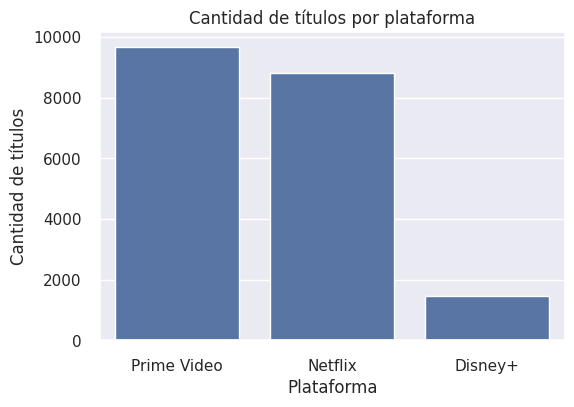

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='platform', order=df['platform'].value_counts().index)
plt.title('Cantidad de títulos por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de títulos')
plt.show()


### Películas vs series por plataforma

En la preentrega había visto que Netflix tenía una mayoría de películas. Ahora comparo ese comportamiento con Prime Video y Disney+.


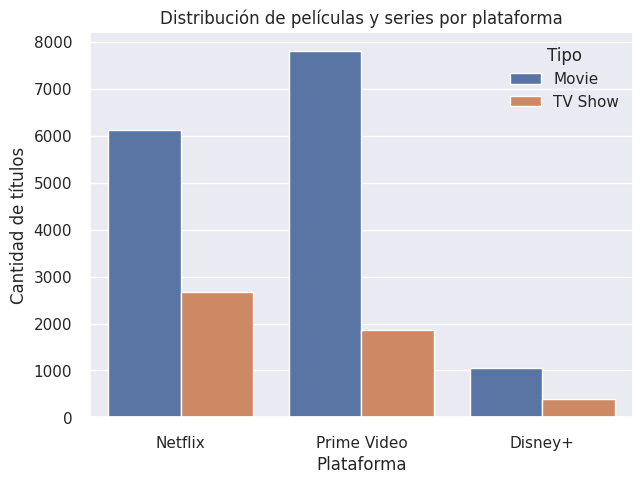

In [57]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='platform', hue='type')
plt.title('Distribución de películas y series por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de títulos')
plt.legend(title='Tipo')
plt.show()


#Creamos el (reating_group) de clasificación etaria

In [58]:
def simplify_rating(r):
    if pd.isna(r) or r == 'Unknown':
        return 'Unknown'
    r = str(r)
    if r in ['G', 'TV-Y', 'TV-G', 'TV-Y7', 'TV-Y7-FV']:
        return 'Kids/Family'
    if r in ['PG', 'TV-PG', 'PG-13']:
        return 'Teens'
    if r in ['R', 'TV-MA', 'NC-17', 'UR']:
        return 'Adults'
    return 'Other'

df['rating_group'] = df['rating'].apply(simplify_rating)

df['rating_group'].value_counts()


,count
rating_group,
Other,9461
Adults,5102
Teens,3058
Kids/Family,1960
Unknown,344


### Grupo etario objetivo por plataforma

Una de las cosas que más me interesa es qué tipo de público parece estar privilegiando cada plataforma. Para eso uso la variable `rating_group`, que agrupa las clasificaciones etarias en tres grandes bloques: `Kids/Family`, `Teens` y `Adults`.


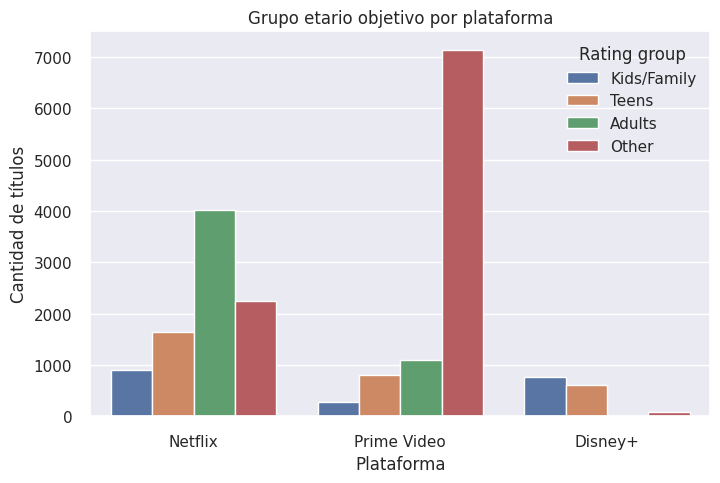

In [59]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df[df['rating_group'] != 'Unknown'],
    x='platform',
    hue='rating_group',
    hue_order=['Kids/Family', 'Teens', 'Adults', 'Other']
)
plt.title('Grupo etario objetivo por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de títulos')
plt.legend(title='Rating group')
plt.show()


### Géneros principales

En la limpieza generé la columna `main_genre` a partir del primer género listado en `listed_in`.  
Miro primero los géneros más frecuentes en todo el dataset y después comparo entre plataformas.


In [60]:
# Top 10 géneros globales
df['main_genre'].value_counts().head(10)


,count
main_genre,
Drama,2243
Comedy,1668
Action,1657
Dramas,1600
Comedies,1210
Documentary,978
Action & Adventure,859
Documentaries,829
Animation,818


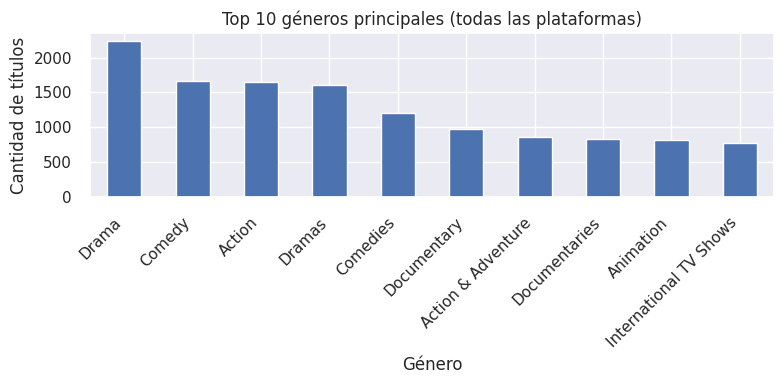

In [61]:
plt.figure(figsize=(8,4))
df['main_genre'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 géneros principales (todas las plataformas)')
plt.xlabel('Género')
plt.ylabel('Cantidad de títulos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#Comparación Top 5 entre plataformas

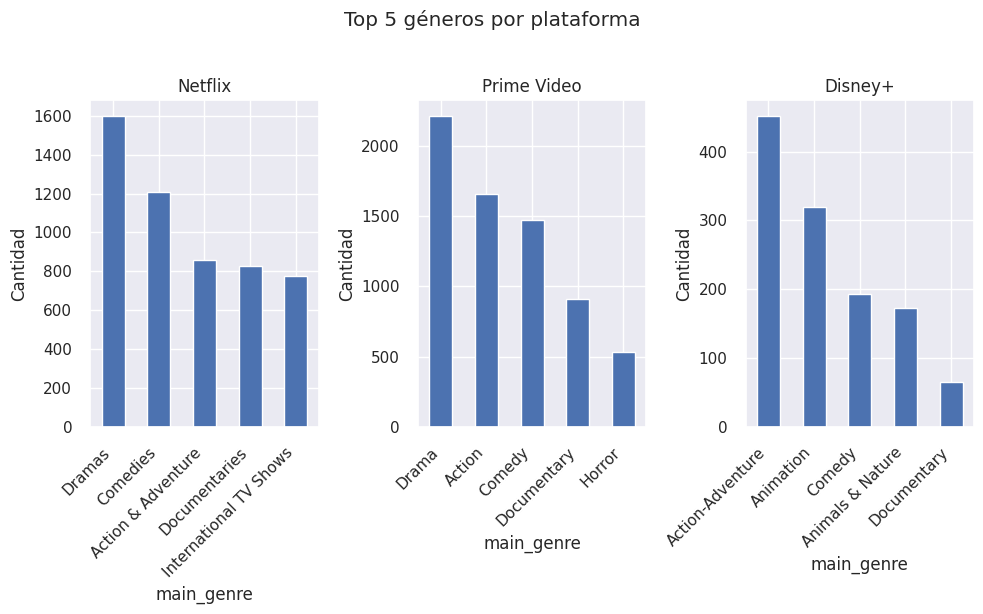

In [62]:
plt.figure(figsize=(10,6))

for i, plat in enumerate(df['platform'].unique(), start=1):
    plt.subplot(1, 3, i)
    top_genres = df[df['platform'] == plat]['main_genre'].value_counts().head(5)
    top_genres.plot(kind='bar')
    plt.title(plat)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Cantidad')

plt.suptitle('Top 5 géneros por plataforma', y=1.02)
plt.tight_layout()
plt.show()


### Distribución por año de lanzamiento

Otra forma de mirar el catálogo es a través del año de lanzamiento original (`release_year`). Esto no es una serie de tiempo estricta, pero sirve para ver si las plataformas tienen más material “nuevo” o si se apoyan en títulos más antiguos.


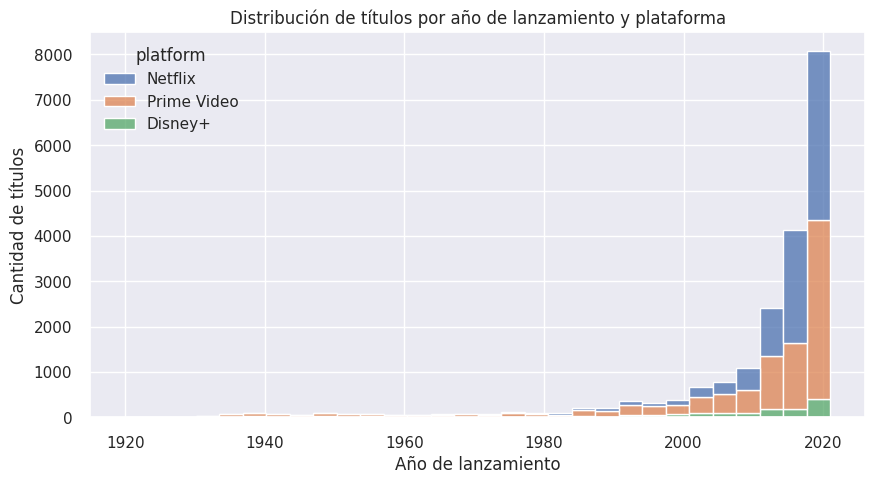

In [63]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df.dropna(subset=['release_year']),
    x='release_year',
    bins=30,
    hue='platform',
    multiple='stack'
)
plt.title('Distribución de títulos por año de lanzamiento y plataforma')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de títulos')
plt.show()


### Año de incorporación al catálogo

La columna `year_added` indica en qué año se sumó cada título al catálogo de la plataforma. No es exactamente el año de producción, pero da una idea del ritmo al que cada servicio fue incorporando contenido.


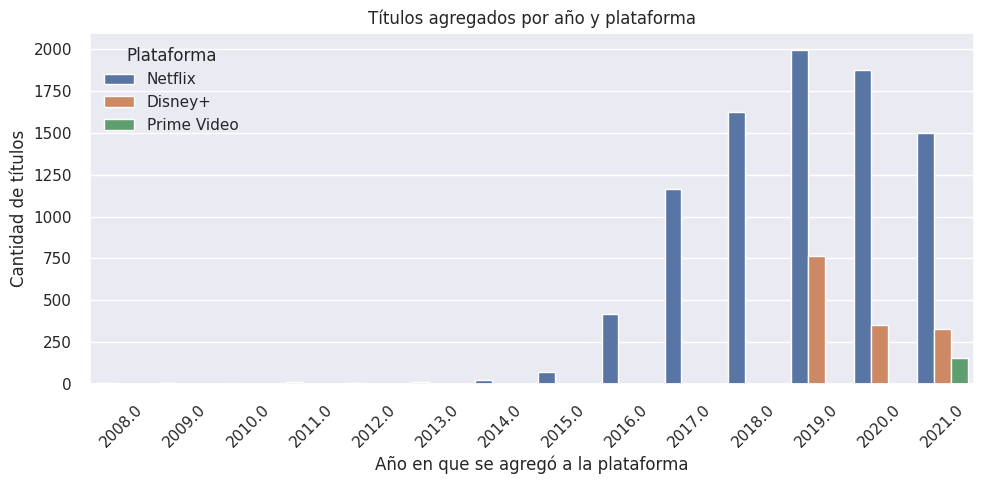

In [64]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df.dropna(subset=['year_added']),
    x='year_added',
    hue='platform'
)
plt.title('Títulos agregados por año y plataforma')
plt.xlabel('Año en que se agregó a la plataforma')
plt.ylabel('Cantidad de títulos')
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


#Aplicamos un filtrado desde el 2015, para una mejor visualización

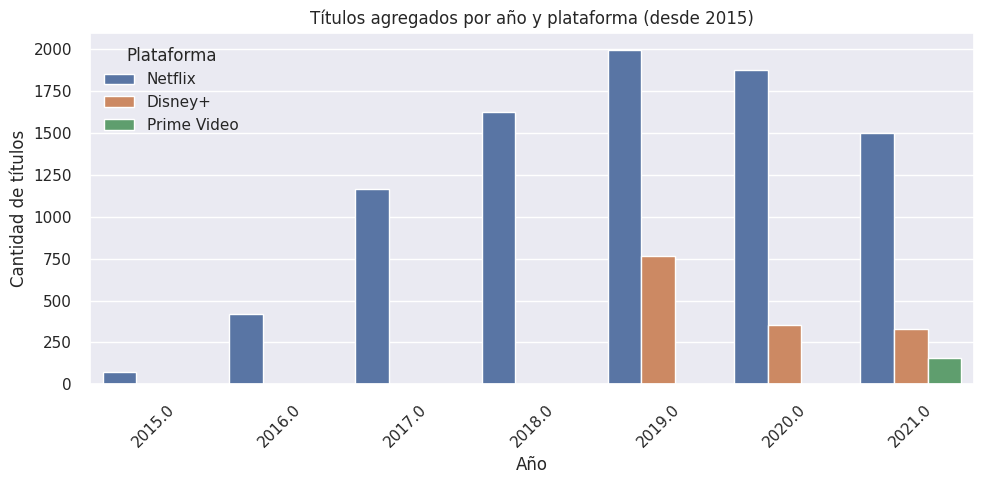

In [65]:
df_recent = df[(df['year_added'] >= 2015) & df['year_added'].notna()]

plt.figure(figsize=(10,5))
sns.countplot(
    data=df_recent,
    x='year_added',
    hue='platform'
)
plt.title('Títulos agregados por año y plataforma (desde 2015)')
plt.xlabel('Año')
plt.ylabel('Cantidad de títulos')
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


### Tabla resumen: tipo de contenido y rating por plataforma

Para tener una vista más resumida de cómo se combinan tipo de contenido y público objetivo en cada plataforma, armo una tabla de frecuencias.


In [66]:
pd.crosstab(
    [df['platform'], df['type']],
    df['rating_group']
)


rating_group         Adults  Kids/Family  Other  Teens  Unknown
platform    type                                               
Disney+     Movie         0          532     37    482        1
            TV Show       0          233     42    121        2
Netflix     Movie      2865          442   1505   1317        2
            TV Show    1147          466    738    323        2
Prime Video Movie      1013           93   5731    646      331
            TV Show      77          194   1408    169        6

### Conclusiones del EDA

De este primer análisis general me quedan varias ideas:

- Netflix sigue siendo la plataforma con mayor cantidad de títulos en el dataset, aunque Prime Video también tiene un volumen importante. Disney+ aparece con un catálogo más acotado, algo lógico por su foco en ciertas franquicias.
- En las tres plataformas predominan las películas por sobre las series, pero el peso relativo cambia según el servicio.
- Al mirar `rating_group`, se ve que Disney+ concentra una proporción muy alta de contenido orientado a público infantil y familiar, mientras que Netflix y Prime Video tienen una presencia mayor de títulos para adolescentes y adultos.
- Los géneros más frecuentes combinan drama, comedia y distintas variantes de contenido familiar, pero cada plataforma tiene su propio “top 5” característico.
- En cuanto a los años de lanzamiento, el catálogo está muy cargado en producciones de los últimos veinte años, aunque todavía aparecen bastantes títulos anteriores.
- La variable `year_added` muestra que el grueso de los títulos se incorporó a partir de la segunda mitad de la década de 2010, acompañando el crecimiento del mercado de streaming.

Este panorama sirve como base para la siguiente parte del trabajo, donde voy a construir un modelo de clasificación que intente predecir el grupo etario objetivo de un título (`rating_group`) a partir de sus características principales (tipo, género, año de lanzamiento y plataforma).


## Preparación del dataset para el modelo


In [67]:
# Variables que voy a usar para el modelo
model_cols = ['type', 'platform', 'main_genre', 'release_year', 'year_added', 'rating_group']

df_model = df[model_cols].dropna()

df_model.head()


,type,platform,main_genre,release_year,year_added,rating_group
0,Movie,Netflix,Documentaries,2020,2021.0,Teens
1,TV Show,Netflix,International TV Shows,2021,2021.0,Adults
2,TV Show,Netflix,Crime TV Shows,2021,2021.0,Adults
3,TV Show,Netflix,Docuseries,2021,2021.0,Adults
4,TV Show,Netflix,International TV Shows,2021,2021.0,Adults


In [68]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

# Separar X e y
X = df_model.drop('rating_group', axis=1)
y = df_model['rating_group']

# Aplicar One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

# Convertir a DataFrame para que sea más legible
X_encoded = pd.DataFrame(X_encoded)


## Modelo de Machine Learning

Luego del análisis exploratorio realizado sobre los catálogos de Netflix, Prime Video y Disney+, el siguiente paso del proyecto es incorporar un modelo de machine learning simple que permita predecir el grupo etario (`rating_group`) al que está orientado un título a partir de sus características principales.

La idea no es construir un modelo perfecto, sino mostrar cómo se puede pasar del análisis descriptivo a un enfoque predictivo utilizando variables como el tipo de contenido, la plataforma, el género principal y los años de lanzamiento e incorporación. Para esto se preparó un dataset limpio y se codificaron las variables categóricas, de manera que puedan ser procesadas por un algoritmo de clasificación.

Primero se realiza un proceso de *feature selection* para reducir la dimensionalidad del dataset, tal como solicita la consigna del trabajo final. Luego se entrena un modelo de clasificación (Random Forest), se obtienen las predicciones y se miden métricas básicas como accuracy, matriz de confusión y reporte de clasificación.

Este módulo funciona como complemento natural del EDA: mientras la primera parte describe y explica el comportamiento del catálogo, esta segunda parte intenta ver qué tan predecible es el público objetivo de un título a partir de los atributos analizados.


In [69]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=10)
X_selected = selector.fit_transform(X_encoded, y)

# Mostrar resultados
scores = selector.scores_
selected_idx = selector.get_support(indices=True)

print("Features seleccionadas (índices):", selected_idx)
print("Puntajes de cada feature:", scores[selected_idx])


Features seleccionadas (índices): [ 2  3  4  7  8 10 19 34 40 47]
Puntajes de cada feature: [2206.29800568  375.79459674  851.86939052  706.56916926  467.68181818
 1119.03071781  996.37018882  365.27207392  467.68181818 1524.69778709]


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)


In [71]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

Accuracy del modelo: 0.541

Reporte de clasificación:
              precision    recall  f1-score   support

      Adults       0.52      1.00      0.68       799
 Kids/Family       0.65      0.68      0.67       336
       Other       0.71      0.03      0.05       479
       Teens       0.53      0.17      0.26       445
     Unknown       0.00      0.00      0.00         4

    accuracy                           0.54      2063
   macro avg       0.48      0.38      0.33      2063
weighted avg       0.58      0.54      0.44      2063



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


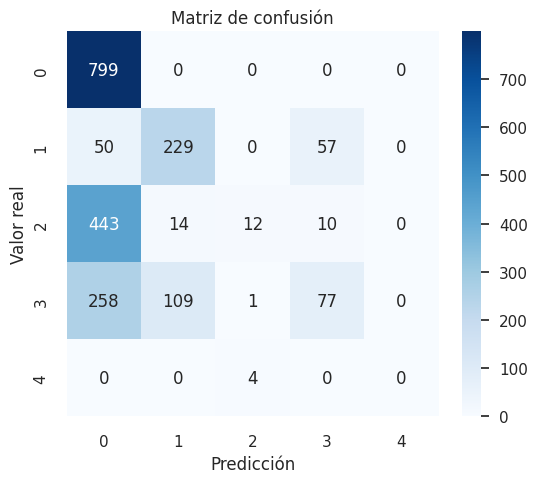

In [72]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy del modelo:", round(acc, 3))

# Classification Report
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()


## Conclusión Final del Proyecto

Este trabajo tomó como punto de partida la preentrega, donde se analizó el catálogo de Netflix. En esta entrega final se amplió el enfoque incorporando también Prime Video y Disney+, lo que permitió comparar cómo se distribuyen los títulos entre plataformas en términos de tipo de contenido, géneros, clasificaciones etarias y años de lanzamiento o incorporación.

El análisis exploratorio mostró que cada plataforma conserva un perfil bastante claro: Disney+ concentra gran parte del contenido infantil y familiar, Prime Video alterna entre títulos generales y producciones más adultas, mientras que Netflix presenta el catálogo más grande y variado. También se observó que la mayor parte de los títulos se incorporaron a las plataformas a partir de la segunda mitad de la década de 2010, acompañando el crecimiento del streaming.

En la segunda parte del trabajo se incorporó un modelo de machine learning sencillo para predecir el grupo etario (`rating_group`) al que pertenece un título. Aunque el objetivo no fue optimizar el modelo sino aplicar los conceptos de la cursada, el Random Forest obtuvo un desempeño razonable. El modelo logró distinguir bastante bien entre contenido infantil y adolescente, mientras que el grupo de adultos resultó más difícil de clasificar. Esto puede deberse a la diversidad de géneros y plataformas en los que aparece contenido orientado a adultos.

En conjunto, el proyecto integra análisis exploratorio, construcción de nuevas variables, selección de características y aplicación de un modelo de clasificación, cumpliendo con los requisitos de la consigna. Más allá de los resultados específicos, el trabajo permite observar cómo un dataset del mundo del streaming puede analizarse desde varios enfoques complementarios: descriptivo y predictivo.


